# H3 – Bewölkungsgrad vs. Prognosefehler

| | |
|---|---|
| **Hypothese** | Die Prognosegenauigkeit korreliert negativ mit dem Bewölkungsgrad – an stark bewölkten Tagen sinkt die Vorhersagequalität. |
| **Typ** | Zusammenhangshypothese / gerichtet |
| **H₀** | Kein (oder positiver) Zusammenhang zwischen Bewölkungsgrad und Prognosefehler |
| **H₃** | Je höher der Bewölkungsgrad, desto größer der Prognosefehler. |
| **Testverfahren** | Korrelationsanalyse |

## 0 · Setup

In [21]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_LR = Path('../../results/01_linear_regression')
RESULTS_RF = Path('../../results/02_random_forest')

MODEL_SPECS = [
    ('Linear Regression BASE', 'linear_regression_base', RESULTS_LR),
    ('Linear Regression + Time', 'linear_regression_base_with_time', RESULTS_LR),
    ('Random Forest BASE', 'random_forest_base', RESULTS_RF),
    ('Random Forest + Time', 'random_forest_base_with_time', RESULTS_RF),
    ('Random Forest + Time + Lag', 'random_forest_base_with_time_and_lag', RESULTS_RF),
]

MODEL_ORDER = [name for name, _, _ in MODEL_SPECS]
MODEL_COLORS = {
    'Linear Regression BASE': '#4C72B0',
    'Linear Regression + Time': '#6B8FD6',
    'Random Forest BASE': '#DD8452',
    'Random Forest + Time': '#E9A26E',
    'Random Forest + Time + Lag': '#C44E52',
}

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})


## 1 · Vorhersagen laden & mit Cloud-Cover-Feature mergen

In [22]:
predictions = {}
for model_name, model_key, results_dir in MODEL_SPECS:
    pred = load_predictions(results_dir, model_key, split='val')
    predictions[model_name] = pred

merged_df = pd.read_csv('../../data/processed/merged.csv', parse_dates=['timestamp'])
merged_df = merged_df.set_index('timestamp')

idx = merged_df.index
for pred in predictions.values():
    idx = idx.intersection(pred.index)

features = merged_df.loc[idx][['cloud_cover_low', 'ghi_cloudy_sky', 'ghi_clear_sky']]

data_by_model = {}
for model_name, pred in predictions.items():
    pred = pred.loc[idx].copy()
    pred['abs_error'] = (pred['y_true'] - pred['y_pred']).abs()
    model_data = pd.concat([pred[['abs_error', 'y_pred', 'y_true']], features], axis=1).dropna()
    data_by_model[model_name] = model_data

print(f"Val-Set (aligned): {idx.min().date()} -> {idx.max().date()}  ({len(idx):,} Zeitschritte)")
print(f"Modelle in Analyse: {', '.join(MODEL_ORDER)}")

Val-Set (aligned): 2024-06-14 -> 2024-12-15  (17,643 Zeitschritte)
Modelle in Analyse: Linear Regression BASE, Linear Regression + Time, Random Forest BASE, Random Forest + Time, Random Forest + Time + Lag


## 2 · Korrelationsanalyse


In [23]:
def _one_sided_p_from_two_sided(corr_value, p_two_sided):
    if np.isnan(corr_value) or np.isnan(p_two_sided):
        return np.nan
    return p_two_sided / 2 if corr_value > 0 else 1 - p_two_sided / 2


def correlation_test(data, feature_name, model_name):
    """Compute Pearson & Spearman between selected feature and abs_error (H3: rho > 0)."""
    subset = data[[feature_name, 'abs_error']].dropna()
    n = int(len(subset))

    if n < 3 or subset[feature_name].nunique() < 2 or subset['abs_error'].nunique() < 2:
        return {
            'Modell': model_name,
            'Feature': feature_name,
            'n': n,
            'Pearson r': np.nan,
            'Pearson p (1-s.)': np.nan,
            'Spearman ρ': np.nan,
            'Spearman p (1-s.)': np.nan,
            f'H₃ (Spearman, α={ALPHA})': False,
        }

    x = subset[feature_name].values
    y = subset['abs_error'].values

    pearson_r, pearson_p_two = stats.pearsonr(x, y)
    spearman_r, spearman_p_two = stats.spearmanr(x, y)

    pearson_p_one = _one_sided_p_from_two_sided(pearson_r, pearson_p_two)
    spearman_p_one = _one_sided_p_from_two_sided(spearman_r, spearman_p_two)

    return {
        'Modell': model_name,
        'Feature': feature_name,
        'n': n,
        'Pearson r': pearson_r,
        'Pearson p (1-s.)': pearson_p_one,
        'Spearman ρ': spearman_r,
        'Spearman p (1-s.)': spearman_p_one,
        f'H₃ (Spearman, α={ALPHA})': spearman_p_one < ALPHA and spearman_r > 0,
    }

corr_rows = []
for model_name in MODEL_ORDER:
    corr_rows.append(correlation_test(data_by_model[model_name], 'cloud_cover_low', model_name))

corr_df = pd.DataFrame(corr_rows).set_index('Modell').reindex(MODEL_ORDER)
display(corr_df.round(4))

,Feature,n,Pearson r,Pearson p (1-s.),Spearman ρ,Spearman p (1-s.),"H₃ (Spearman, α=0.05)"
Modell,,,,,,,
Linear Regression BASE,cloud_cover_low,17643,-0.1654,1.0000,-0.3186,1.0,False
Linear Regression + Time,cloud_cover_low,17643,-0.0281,0.9999,0.1029,0.0,True
Random Forest BASE,cloud_cover_low,17643,-0.1616,1.0000,-0.2906,1.0,False
Random Forest + Time,cloud_cover_low,17643,-0.0633,1.0000,-0.1029,1.0,False
Random Forest + Time + Lag,cloud_cover_low,17643,-0.0601,1.0000,-0.0833,1.0,False


## 3 · Interpretation


In [24]:
print(f"{'='*78}")
print("  H3-TEST: Korrelation Bewölkung vs. Prognosefehler")
print("  Datengrundlage: Gesamtdatensatz, Val-Set")
print(f"  alpha = {ALPHA}, einseitig (H3: rho > 0)")
print(f"{'='*78}")

for model_name in MODEL_ORDER:
    row = corr_df.loc[model_name]
    confirmed = row[f'H₃ (Spearman, α={ALPHA})']
    rho = row['Spearman ρ']
    p = row['Spearman p (1-s.)']
    r_pearson = row['Pearson r']
    verdict = 'H3 BESTÄTIGT' if confirmed else 'H3 WIDERLEGT'
    direction = 'positiv' if pd.notna(rho) and rho > 0 else 'negativ/kein Effekt'

    print(f"\n  {model_name}")
    print(f"    n = {int(row['n'])}")
    print(f"    Spearman rho = {rho:+.4f} ({direction})")
    print(f"    Pearson r    = {r_pearson:+.4f} (Referenz)")
    print(f"    p (1-seitig) = {p:.4f} -> {verdict}")

print(f"\n{'='*78}")


  H3-TEST: Korrelation Bewölkung vs. Prognosefehler
  Datengrundlage: Gesamtdatensatz, Val-Set
  alpha = 0.05, einseitig (H3: rho > 0)

  Linear Regression BASE
    n = 17643
    Spearman rho = -0.3186 (negativ/kein Effekt)
    Pearson r    = -0.1654 (Referenz)
    p (1-seitig) = 1.0000 -> H3 WIDERLEGT

  Linear Regression + Time
    n = 17643
    Spearman rho = +0.1029 (positiv)
    Pearson r    = -0.0281 (Referenz)
    p (1-seitig) = 0.0000 -> H3 BESTÄTIGT

  Random Forest BASE
    n = 17643
    Spearman rho = -0.2906 (negativ/kein Effekt)
    Pearson r    = -0.1616 (Referenz)
    p (1-seitig) = 1.0000 -> H3 WIDERLEGT

  Random Forest + Time
    n = 17643
    Spearman rho = -0.1029 (negativ/kein Effekt)
    Pearson r    = -0.0633 (Referenz)
    p (1-seitig) = 1.0000 -> H3 WIDERLEGT

  Random Forest + Time + Lag
    n = 17643
    Spearman rho = -0.0833 (negativ/kein Effekt)
    Pearson r    = -0.0601 (Referenz)
    p (1-seitig) = 1.0000 -> H3 WIDERLEGT



## 4 · Visualisierung

### 4.1 – Scatterplot: Bewölkungsgrad vs. Fehler


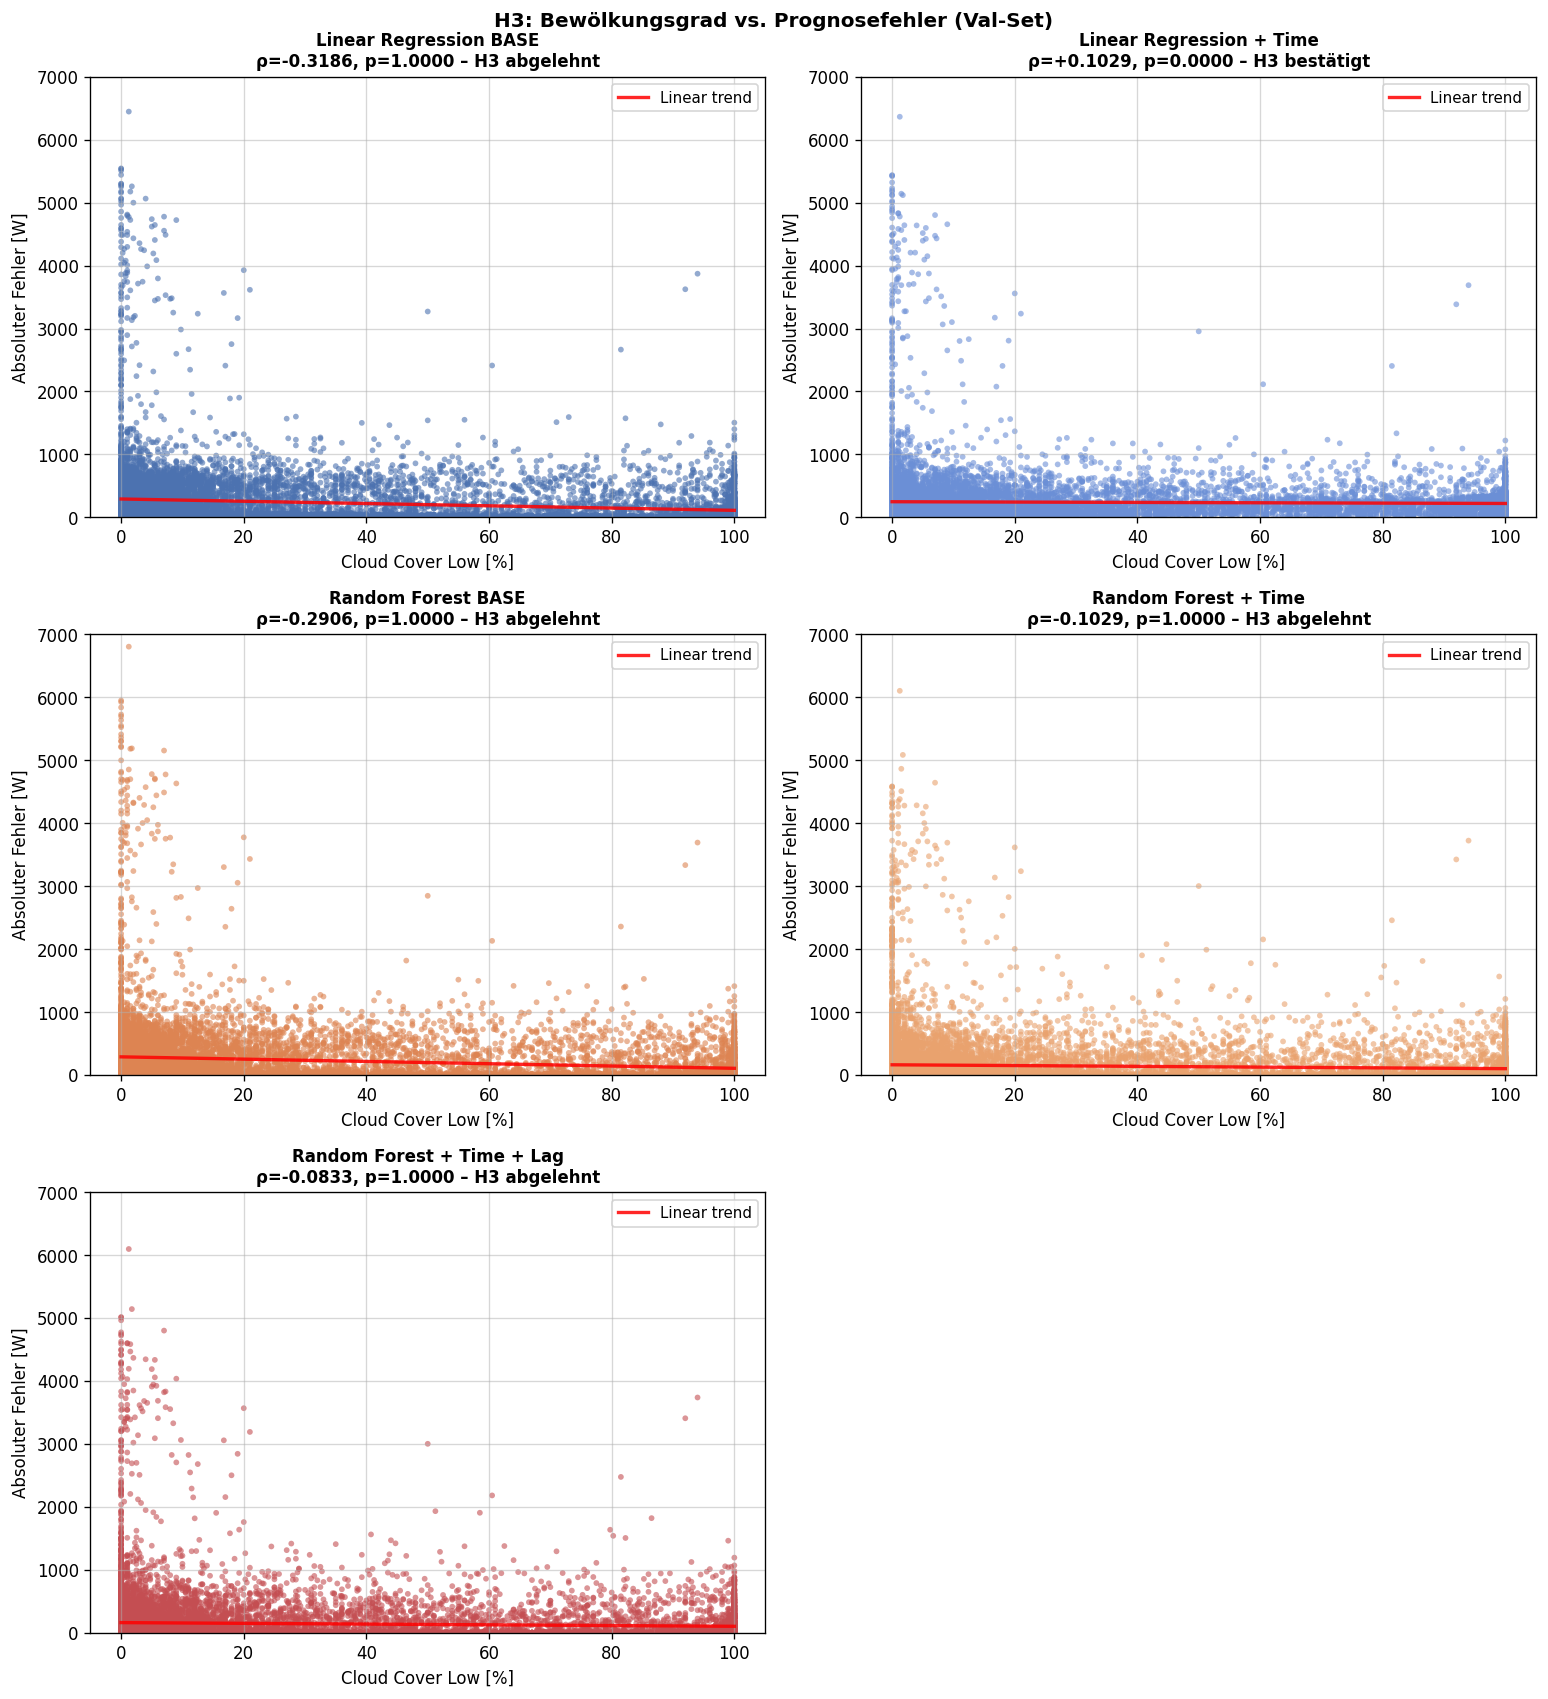

In [25]:
n_models = len(MODEL_ORDER)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.8 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

model_data = [
    (model_name, MODEL_COLORS.get(model_name, '#333333'), data_by_model[model_name])
    for model_name in MODEL_ORDER
]

# Shared y-axis range for direct visual comparability
global_y_max = max(data_by_model[name]['abs_error'].max() for name in MODEL_ORDER)
y_limit = np.ceil(global_y_max / 500) * 500
y_ticks = np.arange(0, y_limit + 1, 1000)

for ax, (model_name, color, data) in zip(axes, model_data):
    row = corr_df.loc[model_name]
    rho = row['Spearman ρ']
    p = row['Spearman p (1-s.)']
    confirmed = row[f'H₃ (Spearman, α={ALPHA})']

    ax.scatter(
        data['cloud_cover_low'],
        data['abs_error'],
        alpha=0.6,
        s=12,
        color=color,
        edgecolor='none',
    )

    if data['cloud_cover_low'].nunique() > 1:
        z = np.polyfit(data['cloud_cover_low'], data['abs_error'], 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(data['cloud_cover_low'].min(), data['cloud_cover_low'].max(), 100)
        ax.plot(x_line, p_fit(x_line), color='red', lw=2, alpha=0.85, label='Linear trend')

    verdict = 'H3 bestätigt' if confirmed else 'H3 abgelehnt'
    title_text = f"{model_name}\nρ={rho:+.4f}, p={p:.4f} – {verdict}"
    ax.set_title(title_text, fontsize=10, fontweight='bold')
    ax.set_xlabel('Cloud Cover Low [%]')
    ax.set_ylabel('Absoluter Fehler [W]')
    ax.tick_params(labelleft=True)
    ax.set_ylim(0, y_limit)
    ax.set_yticks(y_ticks)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.5)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('H3: Bewölkungsgrad vs. Prognosefehler (Val-Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2 – Fehler pro Bewölkungsgrad-Bin


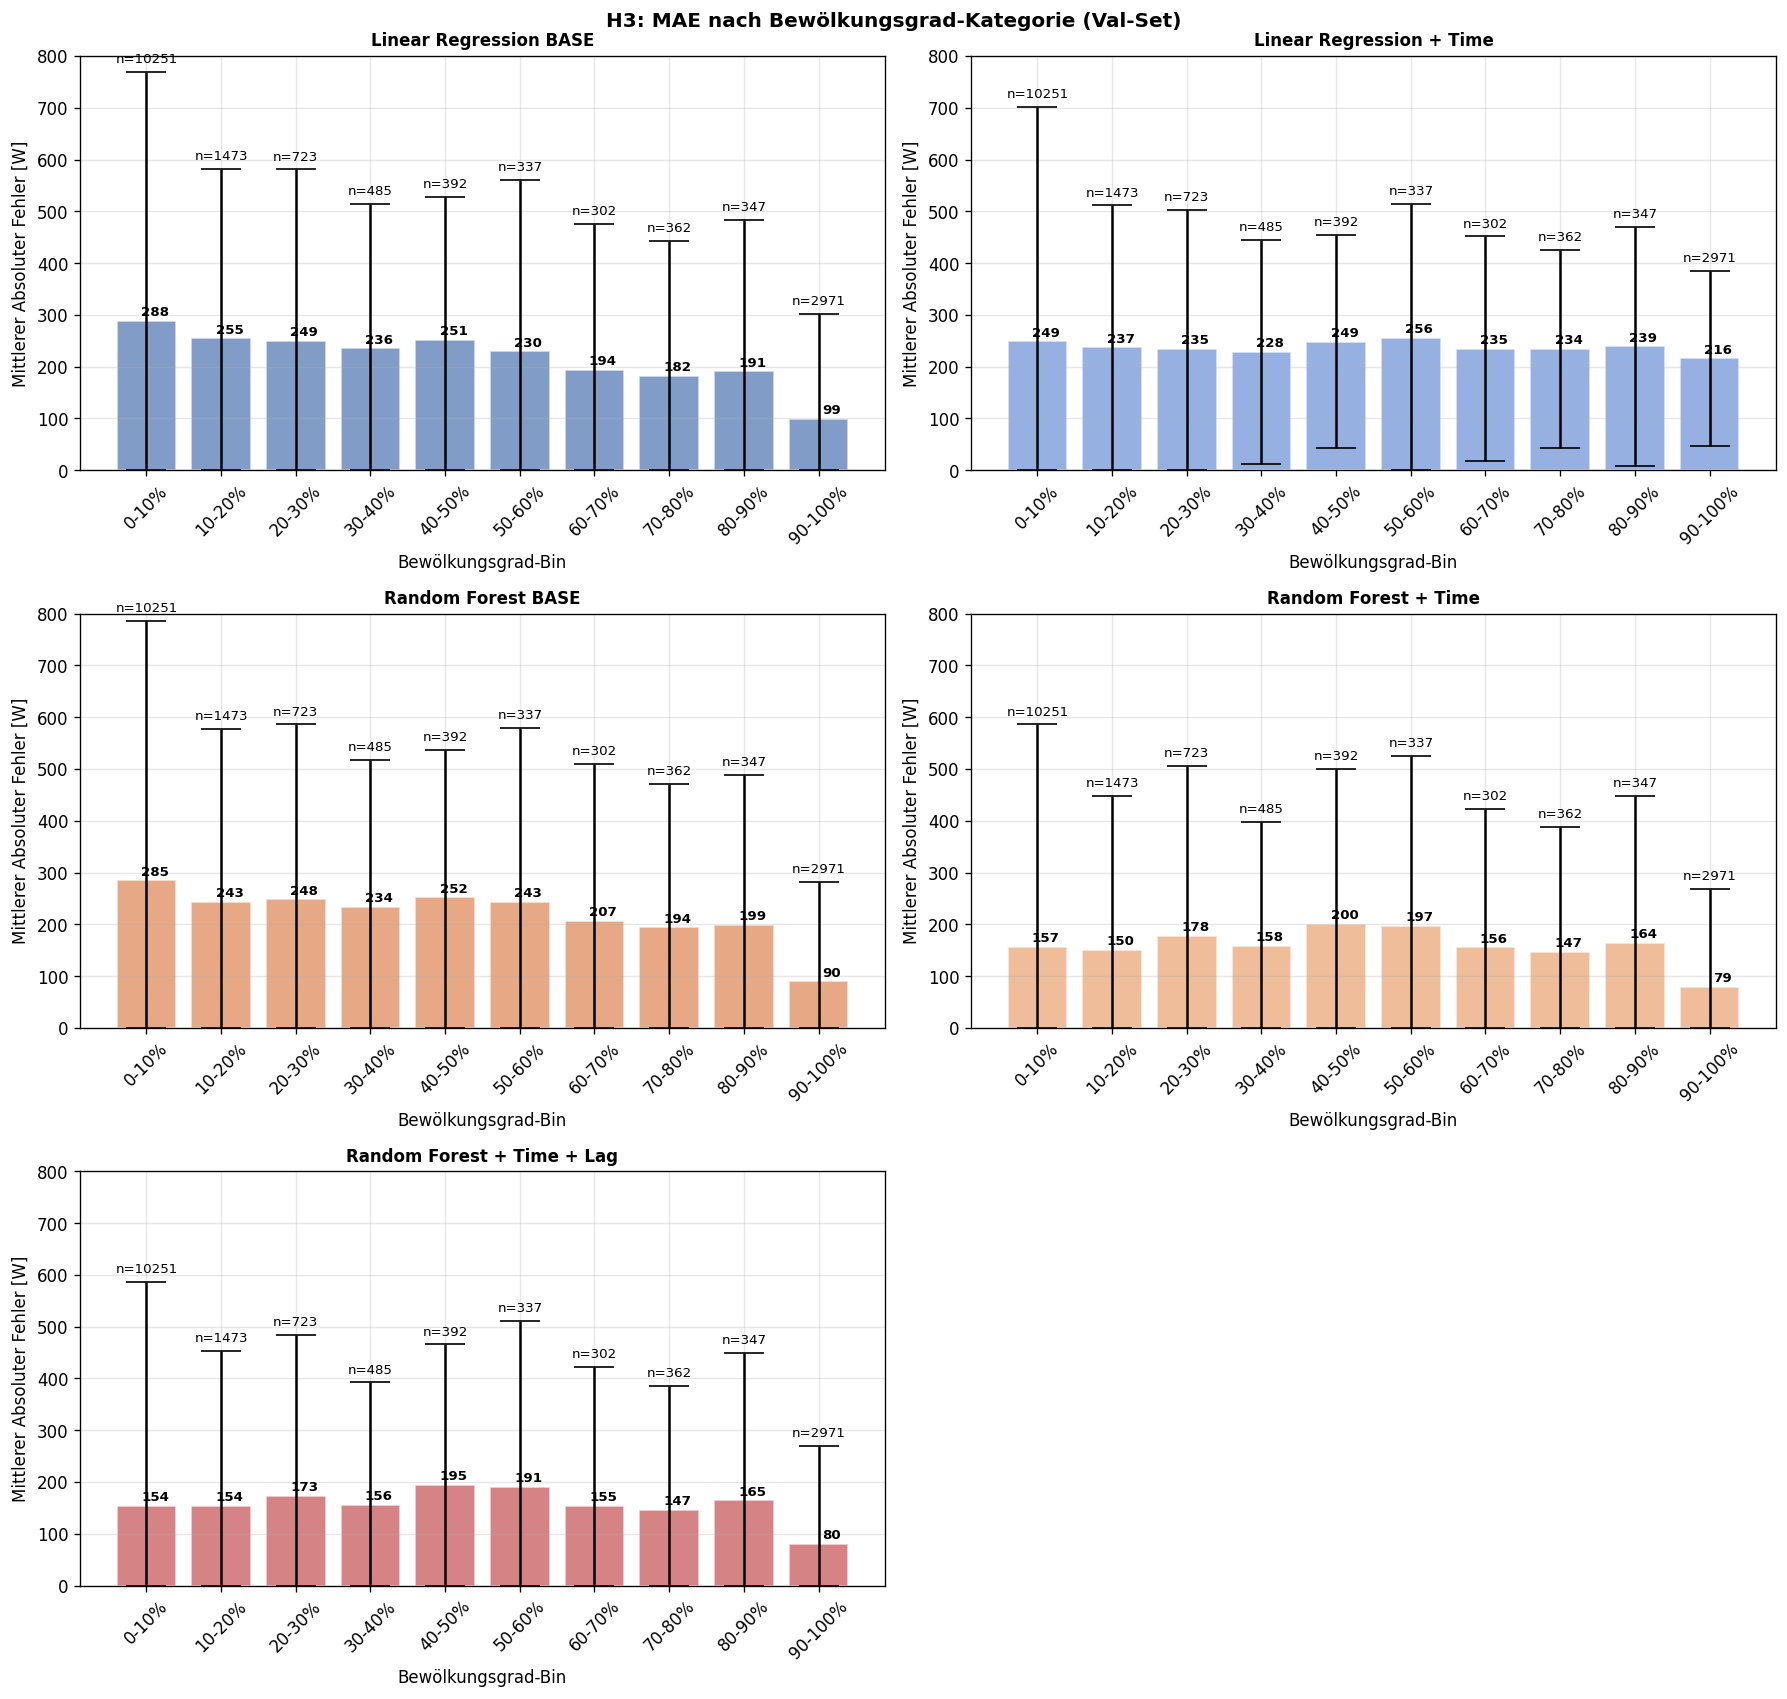

In [26]:
n_models = len(MODEL_ORDER)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

bins = list(range(0, 100, 10)) + [101]
bin_labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)]
model_data = [
    (model_name, MODEL_COLORS.get(model_name, '#333333'), data_by_model[model_name])
    for model_name in MODEL_ORDER
]

binned_results = []

for model_name, color, data in model_data:
    data_copy = data.copy()
    data_copy['bin'] = pd.cut(
        data_copy['cloud_cover_low'],
        bins=bins,
        labels=bin_labels,
        right=False,
        include_lowest=True,
    )

    binned = data_copy.groupby('bin', observed=True)['abs_error'].agg(['mean', 'std', 'count'])
    lower_err = np.minimum(binned['std'].fillna(0), binned['mean'])
    upper_err = binned['std'].fillna(0)
    binned_results.append((model_name, color, binned, lower_err, upper_err))

y_limit = 800
y_ticks = np.arange(0, y_limit + 1, 100)

for ax, (model_name, color, binned, lower_err, upper_err) in zip(axes, binned_results):
    ax.bar(
        range(len(binned)),
        binned['mean'],
        yerr=[lower_err, upper_err],
        color=color,
        alpha=0.7,
        capsize=12,
        edgecolor='white',
        linewidth=1,
    )
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(binned.index, rotation=45)
    ax.set_ylabel('Mittlerer Absoluter Fehler [W]')
    ax.set_xlabel('Bewölkungsgrad-Bin')
    ax.set_title(f'{model_name}', fontsize=10, fontweight='bold')
    ax.set_ylim(0, y_limit)
    ax.set_yticks(y_ticks)
    ax.grid(axis='y', alpha=0.3)

    for i, mean in enumerate(binned['mean']):
        ax.text(i + 0.30, mean + 4, f'{mean:.0f}', ha='right', va='bottom', fontsize=8, fontweight='bold')

    for i, (mean, count, upper) in enumerate(zip(binned['mean'], binned['count'], upper_err)):
        ax.text(i, mean + upper + 18, f'n={int(count)}', ha='center', fontsize=8)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('H3: MAE nach Bewölkungsgrad-Kategorie (Val-Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5 · Fazit


In [27]:
print('=' * 70)
print('FAZIT - H3: Bewölkungsgrad vs. Prognosefehler')
print('=' * 70)

print('\n[Haupttest (Val-Set)]')
for model_name in MODEL_ORDER:
    row = corr_df.loc[model_name]
    confirmed = row[f'H₃ (Spearman, α={ALPHA})']
    verdict = 'BESTÄTIGT' if confirmed else 'WIDERLEGT'
    print(f"  {model_name}: rho={row['Spearman ρ']:+.4f}, p={row['Spearman p (1-s.)']:.4f} -> H3 {verdict}")

h3_col = f'H₃ (Spearman, α={ALPHA})'
h3_confirmed_overall = bool(corr_df[h3_col].fillna(False).any())
mean_rho = float(corr_df['Spearman ρ'].mean())

FAZIT - H3: Bewölkungsgrad vs. Prognosefehler

[Haupttest (Val-Set)]
  Linear Regression BASE: rho=-0.3186, p=1.0000 -> H3 WIDERLEGT
  Linear Regression + Time: rho=+0.1029, p=0.0000 -> H3 BESTÄTIGT
  Random Forest BASE: rho=-0.2906, p=1.0000 -> H3 WIDERLEGT
  Random Forest + Time: rho=-0.1029, p=1.0000 -> H3 WIDERLEGT
  Random Forest + Time + Lag: rho=-0.0833, p=1.0000 -> H3 WIDERLEGT


## Für die Präsi

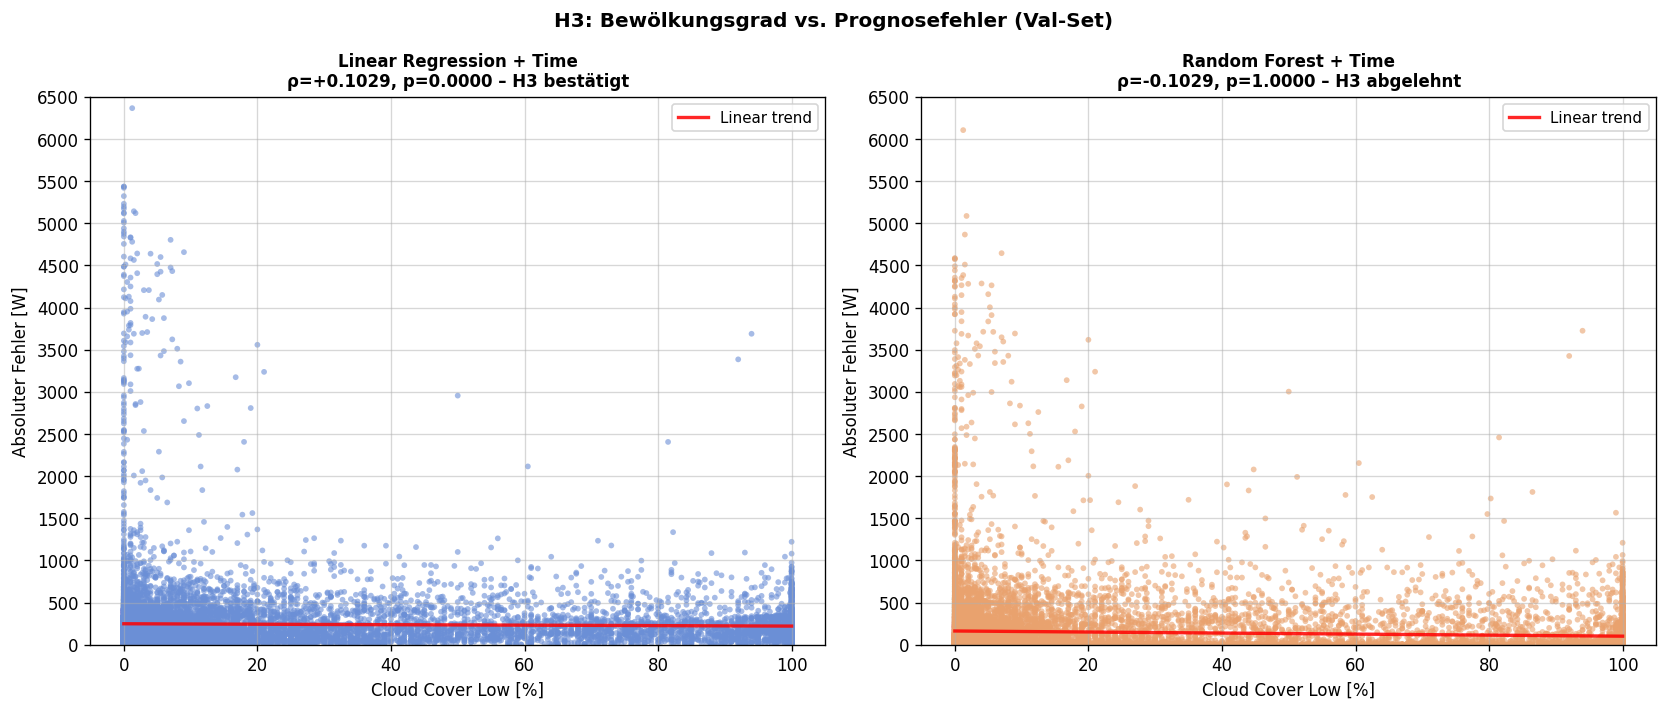

In [28]:
PRESENTATION_MODELS = [
    'Linear Regression + Time',
    'Random Forest + Time',
]

n_models = len(PRESENTATION_MODELS)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

model_data = [
    (model_name, MODEL_COLORS.get(model_name, '#333333'), data_by_model[model_name])
    for model_name in PRESENTATION_MODELS
]

# Shared y-axis range for direct visual comparability
global_y_max = max(data_by_model[name]['abs_error'].max() for name in PRESENTATION_MODELS)
y_limit = np.ceil(global_y_max / 500) * 500
y_ticks = np.arange(0, y_limit + 1, 500)

for ax, (model_name, color, data) in zip(axes, model_data):
    row = corr_df.loc[model_name]
    rho = row['Spearman ρ']
    p = row['Spearman p (1-s.)']
    confirmed = row[f'H₃ (Spearman, α={ALPHA})']

    ax.scatter(
        data['cloud_cover_low'],
        data['abs_error'],
        alpha=0.6,
        s=12,
        color=color,
        edgecolor='none',
    )

    if data['cloud_cover_low'].nunique() > 1:
        z = np.polyfit(data['cloud_cover_low'], data['abs_error'], 1)
        p_fit = np.poly1d(z)
        x_line = np.linspace(data['cloud_cover_low'].min(), data['cloud_cover_low'].max(), 100)
        ax.plot(x_line, p_fit(x_line), color='red', lw=2, alpha=0.85, label='Linear trend')

    verdict = 'H3 bestätigt' if confirmed else 'H3 abgelehnt'
    title_text = f"{model_name}\nρ={rho:+.4f}, p={p:.4f} – {verdict}"
    ax.set_title(title_text, fontsize=10, fontweight='bold')
    ax.set_xlabel('Cloud Cover Low [%]')
    ax.set_ylabel('Absoluter Fehler [W]')
    ax.tick_params(labelleft=True)
    ax.set_ylim(0, y_limit)
    ax.set_yticks(y_ticks)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.5)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('H3: Bewölkungsgrad vs. Prognosefehler (Val-Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


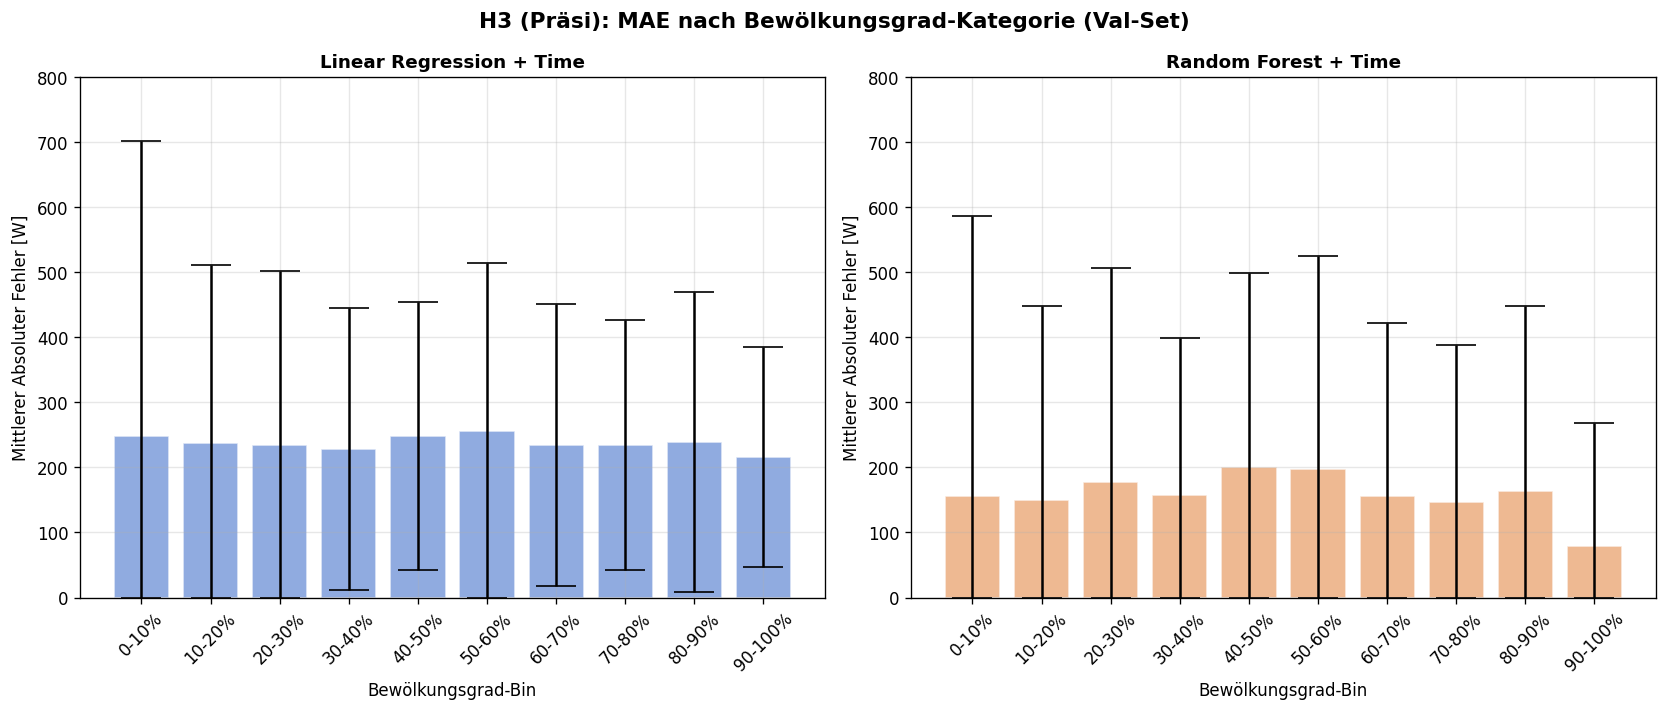

In [42]:
presentation_model_data = [
    (model_name, MODEL_COLORS.get(model_name, '#333333'), data_by_model[model_name])
    for model_name in PRESENTATION_MODELS
]

n_models = len(PRESENTATION_MODELS)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6 * nrows))
axes = np.atleast_1d(axes).ravel()

bins = list(range(0, 100, 10)) + [101]
bin_labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)]

binned_results = []
for model_name, color, data in presentation_model_data:
    data_copy = data.copy()
    data_copy['bin'] = pd.cut(
        data_copy['cloud_cover_low'],
        bins=bins,
        labels=bin_labels,
        right=False,
        include_lowest=True,
    )

    binned = data_copy.groupby('bin', observed=True)['abs_error'].agg(['mean', 'std', 'count'])
    lower_err = np.minimum(binned['std'].fillna(0), binned['mean'])
    upper_err = binned['std'].fillna(0)
    binned_results.append((model_name, color, binned, lower_err, upper_err))

y_limit = 800
y_ticks = np.arange(0, y_limit + 1, 100)

for ax, (model_name, color, binned, lower_err, upper_err) in zip(axes, binned_results):
    ax.bar(
        range(len(binned)),
        binned['mean'],
        yerr=[lower_err, upper_err],
        color=color,
        alpha=0.75,
        capsize=12,
        edgecolor='white',
        linewidth=1,
    )
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(binned.index, rotation=45)
    ax.set_ylabel('Mittlerer Absoluter Fehler [W]')
    ax.set_xlabel('Bewölkungsgrad-Bin')
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_ylim(0, y_limit)
    ax.set_yticks(y_ticks)
    ax.grid(axis='y', alpha=0.3)
    
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('H3 (Präsi): MAE nach Bewölkungsgrad-Kategorie (Val-Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()